# lab 2 - image transform algorithms implementation

## 0. Preparing data

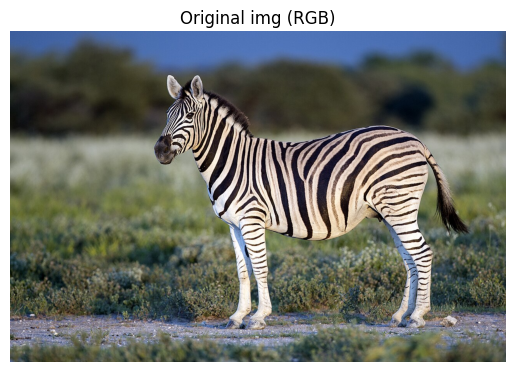

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


img_bgr = cv2.imread('zebra.png') 
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original img (RGB)")
plt.axis('off')
plt.show()

In [46]:
def compare_imgs(custom_img, cv2_img, title):
    plt.figure(figsize=(12, 5))
    plt.title(title, fontsize=20)
    plt.axis('off')

    plt.subplot(1, 2, 1)
    plt.title('Custom', fontsize=18)
    plt.imshow(custom_img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('OpenCV', fontsize=18)
    plt.imshow(cv2_img)
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    

## 1. Conversions between color spaces

### RGV -> HSV

In [57]:
def rgb_to_hsv(rgb):
    rgb = rgb.astype('float') / 255.0
    hsv = np.zeros_like(rgb)
    
    r = rgb[..., 0]
    g = rgb[..., 1]
    b = rgb[..., 2]
    
    maxc = np.max(rgb, axis=-1)
    minc = np.min(rgb, axis=-1)
    v = maxc
    
    # Расчет насыщенности (Saturation)
    delta = maxc - minc
    s = delta / (maxc + 1e-7)
    s[maxc == 0] = 0
    
    # Расчет оттенка (Hue)
    h = np.zeros_like(maxc)
    
    # Для maxc == minc (оттенки серого), H=0
    div_safe = np.zeros_like(delta)
    np.divide(1.0, delta, out=div_safe, where=delta != 0)

    mask_r = (maxc == r) & (delta != 0)
    mask_g = (maxc == g) & (delta != 0)
    mask_b = (maxc == b) & (delta != 0)

    h[mask_r] = ((g - b) * div_safe)[mask_r]
    h[mask_g] = (2.0 + (b - r) * div_safe)[mask_g]
    h[mask_b] = (4.0 + (r - g) * div_safe)[mask_b]
    
    h = (h / 6.0) % 1.0 # Нормализация в 0-1
    h[h < 0] += 1.0 # Обработка отрицательных значений
    
    hsv[..., 0] = h
    hsv[..., 1] = s
    hsv[..., 2] = v
    
    return hsv  

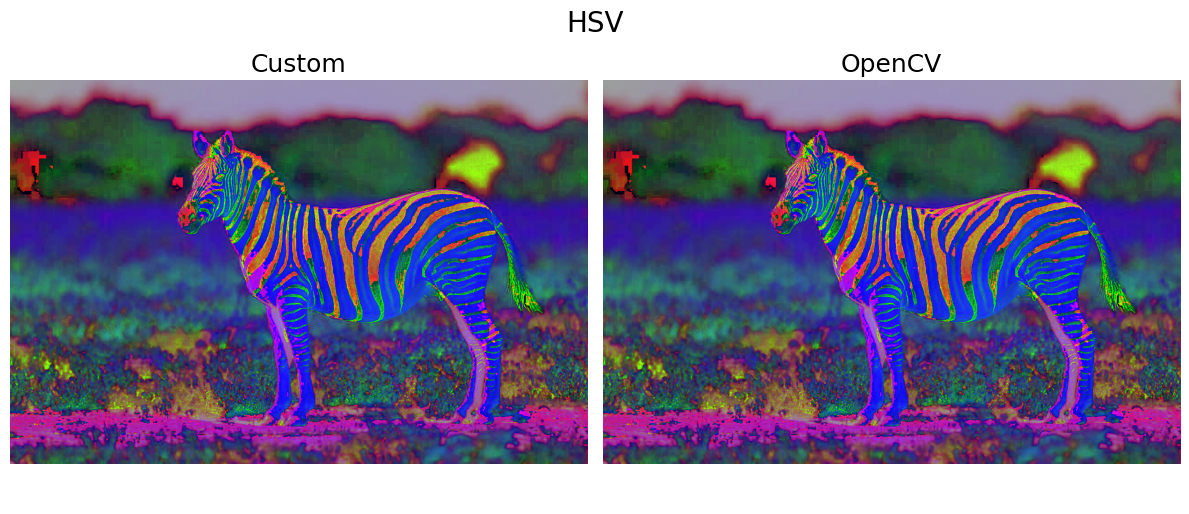

In [58]:
hsv_custom = rgb_to_hsv(img_rgb)

# OpenCV выдает H в диапазоне 0-179, S и V в 0-255
hsv_cv2 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Чтобы графики были сопоставимы, приведем их к одному масштабу (0-1)
hsv_cv2_norm = hsv_cv2.astype('float') / [179, 255, 255]

compare_imgs(hsv_custom, hsv_cv2_norm, 'HSV')

### RGB -> HSL

In [59]:
def rgb_to_hsl(rgb):
    # Нормализация в [0, 1]
    rgb = rgb.astype('float') / 255.0
    r = rgb[..., 0]
    g = rgb[..., 1]
    b = rgb[..., 2]

    maxc = np.max(rgb, axis=-1)
    minc = np.min(rgb, axis=-1)
    delta = maxc - minc

    l = (maxc + minc) / 2.0

    s = np.zeros_like(l)
    # Формула S меняется в зависимости от L
    mask_s = (delta != 0)
    denom = 1.0 - np.abs(2.0 * l - 1.0)
    s[mask_s] = delta[mask_s] / denom[mask_s]

    h = np.zeros_like(l)
    
    div_safe = np.zeros_like(delta)
    np.divide(1.0, delta, out=div_safe, where=delta != 0)

    mask_r = (maxc == r) & (delta != 0)
    mask_g = (maxc == g) & (delta != 0)
    mask_b = (maxc == b) & (delta != 0)

    h[mask_r] = ((g - b) * div_safe)[mask_r] % 6
    h[mask_g] = ((b - r) * div_safe)[mask_g] + 2.0
    h[mask_b] = ((r - g) * div_safe)[mask_b] + 4.0

    h = (h / 6.0) % 1.0

    # Собираем результат: H (0-1), S (0-1), L (0-1)
    hsl = np.stack([h, s, l], axis=-1)

    return hsl

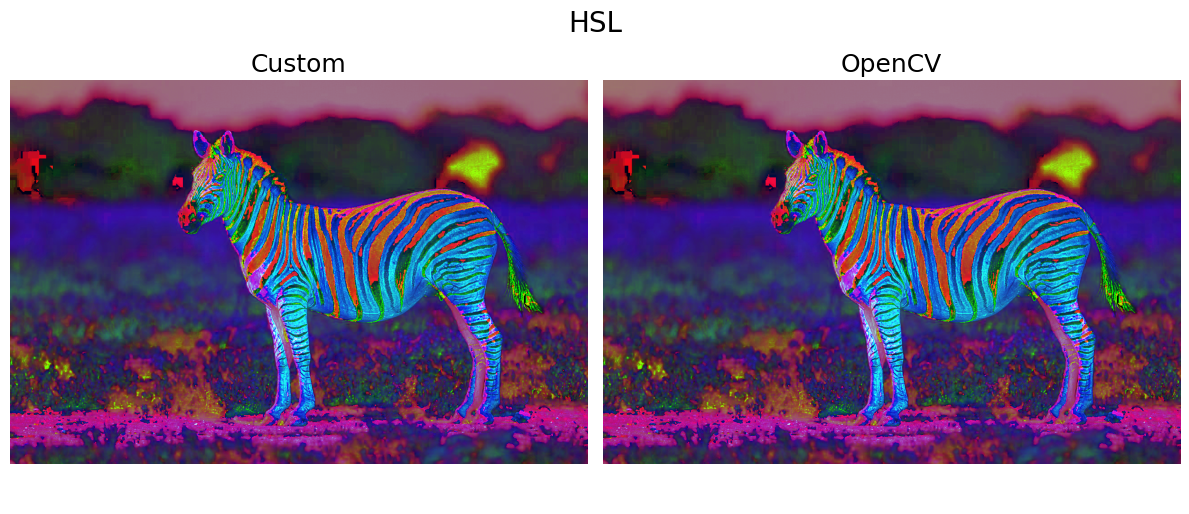

In [62]:
hsl_custom = rgb_to_hsl(img_rgb)

# OpenCV выдает H в диапазоне 0-179, S и V в 0-255
hls_cv2 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS).astype('float')

# В OpenCV порядок H, L, S. Для визуализации переставим в H, S, L
hsl_cv2 = hls_cv2[:, :, [0, 2, 1]]

# Нормализуем OpenCV к диапазону 0-1
# В OpenCV: H=0-179, L=0-255, S=0-255
hsl_cv2_norm = hsl_cv2.astype('float') / [179, 255, 255]

compare_imgs(np.clip(hsl_custom, 0, 1), hsl_cv2_norm, 'HSL')

## Blending (with parameters 𝜶, 𝜷, and 𝜸)

In [67]:
def add_weighted(img1, alpha, img2, beta, gamma):
    # Преобразуем в float, чтобы избежать переполнения при расчетах
    result = img1.astype(float) * alpha + img2.astype(float) * beta + gamma
    
    return np.clip(result, 0, 255).astype(np.uint8)

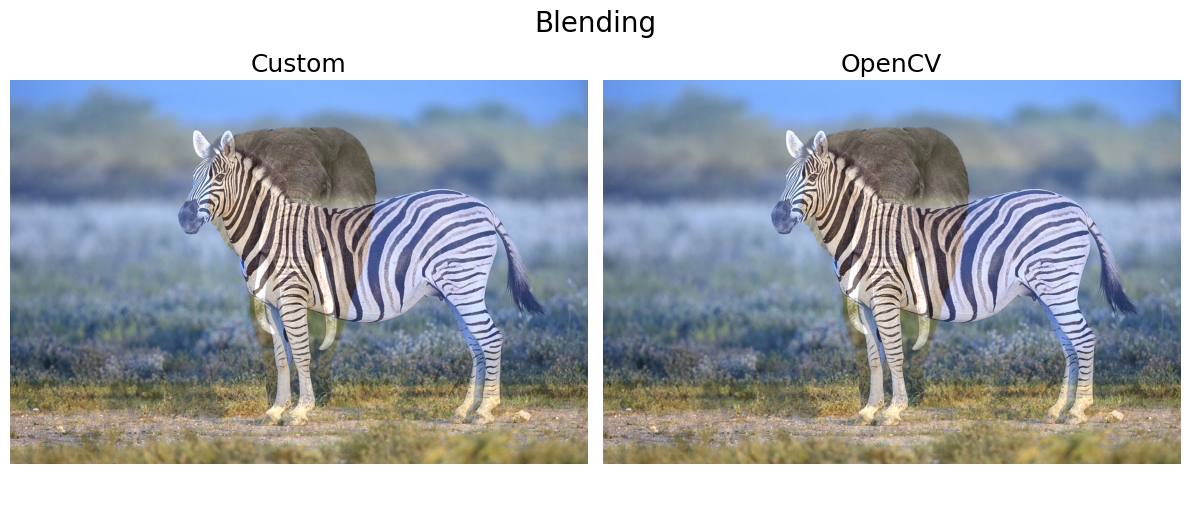

In [71]:
img_bgr2 = cv2.imread('slonyara.png')
img_rgb2 = cv2.cvtColor(img_bgr2, cv2.COLOR_BGR2RGB)

img_rgb2 = cv2.resize(img_rgb2, (img_rgb.shape[1], img_rgb.shape[0])) # подгоняем размер

alpha = 0.7
beta = 0.5
gamma = 10

blended_custom = add_weighted(img_rgb, alpha, img_rgb2, beta, gamma)
blended_cv2 = cv2.addWeighted(img_rgb, alpha, img_rgb2, beta, gamma)

compare_imgs(blended_custom, blended_cv2, 'Blending')

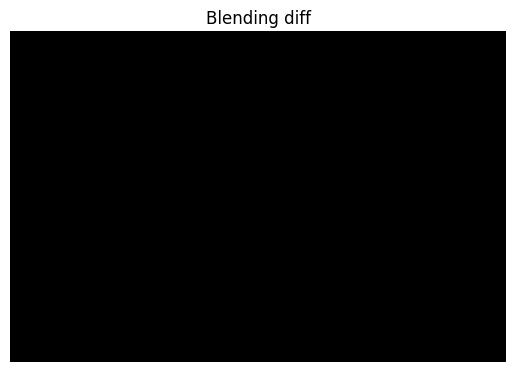

In [73]:
diff = cv2.absdiff(blended_custom, blended_cv2)

plt.imshow(diff)
plt.title('Blending diff')
plt.axis('off')
plt.show()